# Imaging M87* with a Deep Image Prior 🌠 🔭
## A Colab/CUDA tutorial for EHT interferometric imaging

In this notebook we reconstruct a **64 × 64 image of M87** from sparse Event Horizon Telescope (EHT) observables using the Deep Image Prior (DIP) implementation supplied with the school. The network is not trained on a library of black-hole images: its weights are optimized for this single observation.

### Learning goals

By the end, you should be able to:

1. inspect an interferometric data set in the $(u,v)$ plane;
2. connect image pixels to complex visibilities through the Fourier measurement equation;
3. explain how visibility amplitudes, closure phases, a neural parameterization, and explicit regularizers enter the inverse problem;
4. run the reconstruction on a CUDA GPU and assess the result in **data space**; and
5. identify which settings control resolution, robustness, and prior assumptions.

> **Scope.** The short run is designed for an interactive class and demonstrates the workflow. It is not a publication-quality convergence study. A scientific analysis requires longer runs, multiple random seeds, hyperparameter tests, and multiple bootstrap realizations.

## 0. Before you run anything:

In Colab, select **Runtime → Change runtime type → T4 GPU** (or another CUDA GPU), then choose **Runtime → Run all**.

Keep these two course files ready; the setup cell will request them if they are not already in `/content`:

- `eht_dip.py` — reconstruction model and optimizer
- `SR1_M87_2017_095_lo_hops_netcal_StokesI.npz` — example visibility-amplitude and closure-phase data
[link text](https://)

In [1]:
# Astropy is used only to export the final image as FITS.
# NumPy, Matplotlib, and a CUDA-enabled PyTorch are preinstalled in Colab.
%pip -q install astropy

In [2]:
from pathlib import Path

CORE_FILE = Path("eht_dip.py")
DATA_FILE = Path("SR1_M87_2017_095_lo_hops_netcal_StokesI.npz")
required_files = [CORE_FILE, DATA_FILE]
missing = [path.name for path in required_files if not path.exists()]

if missing:
    try:
        from google.colab import files
    except ImportError as exc:
        raise RuntimeError(
            f"Missing {missing}. Copy them into {Path.cwd()} and rerun this cell."
        ) from exc

    print("Upload BOTH course files listed above.")
    files.upload()

still_missing = [path.name for path in required_files if not path.exists()]
if still_missing:
    raise FileNotFoundError(
        f"Still missing {still_missing}. Upload the file(s), then rerun this cell."
    )

print("Ready:", *[path.name for path in required_files], sep="\n  • " )

Ready:
  • eht_dip.py
  • SR1_M87_2017_095_lo_hops_netcal_StokesI.npz


In [3]:
import shutil
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from astropy.io import fits

from eht_dip import (
    reconstruct_eht_dip,
    reconstruct_eht_dip_bootstrap,
)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is unavailable. In Colab choose Runtime → Change runtime type → GPU, "
        "then rerun from the top."
    )

DEVICE = "cuda"
print(f"PyTorch: {torch.__version__}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"CUDA runtime reported by PyTorch: {torch.version.cuda}")

PyTorch: 2.11.0+cu128
GPU: Tesla T4
CUDA runtime reported by PyTorch: 12.8


## 1. The inverse problem

For a small field of view, an interferometer samples the Fourier transform of the sky brightness $I(l,m)$:

$$V(u,v)=\iint I(l,m)\,e^{-2\pi i(ul+vm)}\,dl\,dm.$$

The supplied code evaluates the corresponding nonuniform discrete Fourier transform directly at the measured coordinates. The data contain:

| Observable | Arrays | Role | Unit used here |
|---|---|---|---|
| Visibility amplitude | `vis`, `vsigma`, sampled at `u`, `v` | Constrains Fourier-modulus structure and flux scale | Jy; $(u,v)$ in wavelengths |
| Closure phase | `cphase`, `sigmacp`, with two baselines per triangle | Robust phase information: $\arg(V_1V_2V_3)$ | degrees |

Because the $(u,v)$ plane is sparsely sampled, many images can agree with the data. DIP writes the image as

$$I_\theta = \operatorname{softplus}[f_\theta(z)],$$

where $z$ is fixed and the convolutional-network parameters $\theta$ are optimized for this one data set. The architecture acts as an **implicit image prior**. Explicit TSV and compactness terms add further assumptions. These are priors, not facts supplied by the measurements.

In [4]:
# Load the archive without allowing pickled Python objects.
with np.load(DATA_FILE, allow_pickle=False) as archive:
    data = {key: np.asarray(archive[key], dtype=np.float32) for key in archive.files}

amp_keys = {"u", "v", "vis", "vsigma"}
cp_keys = {"cphase", "sigmacp", "u1", "v1", "u2", "v2"}
missing_amp = amp_keys.difference(data)
if missing_amp:
    raise KeyError(f"The amplitude data are missing keys: {sorted(missing_amp)}")
if not cp_keys.issubset(data):
    warnings.warn("Closure-phase arrays are incomplete; the reconstruction will use amplitudes only.")

for key, values in data.items():
    if not np.all(np.isfinite(values)):
        raise ValueError(f"{key} contains NaN or infinite values.")
if np.any(data["vsigma"] <= 0):
    raise ValueError("All visibility-amplitude uncertainties must be positive.")
if "sigmacp" in data and np.any(data["sigmacp"] <= 0):
    raise ValueError("All closure-phase uncertainties must be positive.")

print(f"Visibility amplitudes : {data['vis'].size}")
print(f"Closure phases        : {data.get('cphase', np.empty(0)).size}")
print(f"Longest baseline      : {np.hypot(data['u'], data['v']).max()/1e9:.2f} Gλ")
print(f"Amplitude range       : {data['vis'].min():.4f}–{data['vis'].max():.4f} Jy")

Visibility amplitudes : 152
Closure phases        : 118
Longest baseline      : 8.26 Gλ
Amplitude range       : 0.0017–0.3352 Jy


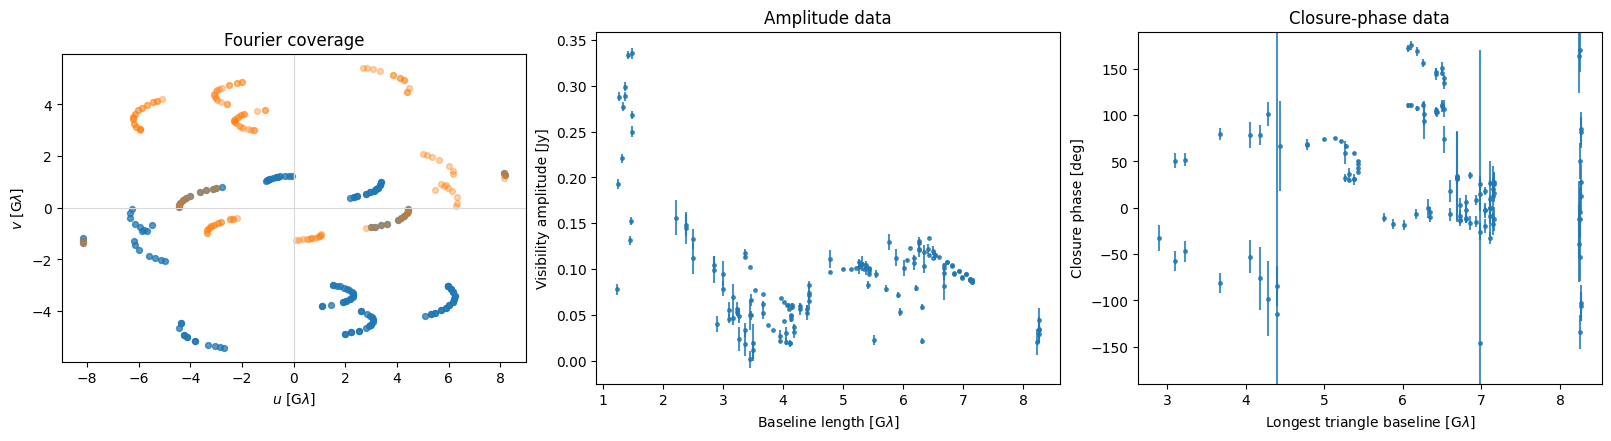

In [5]:
u_glambda = data["u"] / 1e9
v_glambda = data["v"] / 1e9
baseline_glambda = np.hypot(data["u"], data["v"]) / 1e9

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), constrained_layout=True)

# Plot both measured points and their Hermitian conjugates for a real sky image.
axes[0].scatter(u_glambda, v_glambda, s=18, alpha=0.75)
axes[0].scatter(-u_glambda, -v_glambda, s=18, alpha=0.35)
axes[0].axhline(0, color="0.85", lw=0.8)
axes[0].axvline(0, color="0.85", lw=0.8)
axes[0].set(aspect="equal", xlabel=r"$u$ [G$\lambda$]", ylabel=r"$v$ [G$\lambda$]", title="Fourier coverage")

axes[1].errorbar(baseline_glambda, data["vis"], yerr=data["vsigma"], fmt=".", ms=5, alpha=0.8)
axes[1].set(xlabel=r"Baseline length [G$\lambda$]", ylabel="Visibility amplitude [Jy]", title="Amplitude data")

if cp_keys.issubset(data):
    b1 = np.hypot(data["u1"], data["v1"])
    b2 = np.hypot(data["u2"], data["v2"])
    b3 = np.hypot(data["u1"] + data["u2"], data["v1"] + data["v2"])
    triangle_scale_glambda = np.maximum.reduce([b1, b2, b3]) / 1e9
    axes[2].errorbar(triangle_scale_glambda, data["cphase"], yerr=data["sigmacp"], fmt=".", ms=5, alpha=0.8)
    axes[2].set(xlabel=r"Baseline length [G$\lambda$]", ylabel="Closure phase [deg]", title="Closure-phase data", ylim=(-190, 190))
else:
    axes[2].text(0.5, 0.5, "No complete closure-phase data", ha="center", va="center")
    axes[2].set_axis_off()

plt.show()

### Reading these plots

Long baselines probe small angular scales, while gaps and preferred directions in Fourier coverage produce anisotropic ambiguity in the image. Visibility amplitudes discard station-based phase information. Closure phase restores some morphology information because station-based phase errors cancel around a closed triangle, although it does not determine an absolute image position.

A useful order-of-magnitude resolution estimate is $\theta\sim 1/B_{\max}$. Do that calculation from the printed longest baseline and compare it with the pixel size selected below. Pixels should sample the nominal resolution; they should not be mistaken for independent resolution elements.

## 2. Configure the reconstruction

The optimized objective is schematically

$$\mathcal{L}=w_A\mathcal{L}_{t,A}+w_\psi\mathcal{L}_{t,\psi}+\lambda_{\rm TSV}R_{\rm TSV}+\lambda_{\rm comp}R_{\rm comp}+\cdots.$$

The Student-$t$ data terms are more tolerant of outliers than a Gaussian $\chi^2$ loss. Closure-phase residuals are wrapped to $[-\pi,\pi]$. The settings below follow the supplied example runner, except for the number of iterations.

| Setting | Interpretation |
|---|---|
| `NPIX`, `PIXEL_SIZE_UAS` | Image support and angular sampling; field of view is their product |
| `NUM_ITER` | Optimization budget; use the quick value in class and thousands for a serious run |
| `lambda_tsv` | Penalizes squared neighboring-pixel differences (smoothness) |
| `lambda_compact`, `r_compact_uas` | Penalizes emission outside a chosen radius |
| `gauss_fwhm_uas` | Scale of the fixed Gaussian-plus-noise network input |
| `blur_sigma0_pix` | Coarse-to-fine optimization: initial output blur decays to zero |

> Change one assumption at a time and always judge the consequence in observable space, not only by whether the image looks familiar.

In [6]:
# Colab form controls: edit these values, then rerun this and later cells.
QUICK_RUN = False  #@param {type:"boolean"}
NPIX = 64  #@param {type:"integer"}
PIXEL_SIZE_UAS = 2.0  #@param {type:"number"}
QUICK_ITERATIONS = 400  #@param {type:"integer"}
FULL_ITERATIONS = 4000  #@param {type:"integer"}

NUM_ITER = QUICK_ITERATIONS if QUICK_RUN else FULL_ITERATIONS
OUTPUT_DIR = Path("eht_dip_results")
OUTPUT_DIR.mkdir(exist_ok=True)

if NPIX <= 0 or NPIX % 32 != 0:
    raise ValueError("NPIX must be a positive multiple of 32 for this five-level U-Net.")
if PIXEL_SIZE_UAS <= 0 or NUM_ITER <= 0:
    raise ValueError("PIXEL_SIZE_UAS and the iteration count must be positive.")

fov_uas = NPIX * PIXEL_SIZE_UAS
print(f"Mode              : {'quick classroom run' if QUICK_RUN else 'long run'}")
print(f"Image             : {NPIX} × {NPIX} pixels")
print(f"Field of view     : {fov_uas:.1f} μas")
print(f"Optimization steps: {NUM_ITER:,}")
print(f"Outputs           : {OUTPUT_DIR.resolve()}")

Mode              : long run
Image             : 64 × 64 pixels
Field of view     : 128.0 μas
Optimization steps: 4,000
Outputs           : /content/eht_dip_results


In [7]:
torch.cuda.empty_cache()
start = time.perf_counter()

image = reconstruct_eht_dip(
    data_dict=data,
    npix=NPIX,
    pixel_size=PIXEL_SIZE_UAS,
    device=DEVICE,
    save_dir=str(OUTPUT_DIR),
    save_every=None,
    # Relative weights of the two observable types
    amp_weight=1.5,
    cp_weight=1.0,
    # Explicit image regularization
    lambda_tv=0.0,
    lambda_tsv=1.0,
    lambda_l1=0.0,
    lambda_centroid=0.0,
    lambda_flux=0.0,
    target_flux=0.6,  # Inactive while lambda_flux == 0
    lambda_compact=0.5,
    r_compact_uas=40.0,
    lambda_void=0.0,
    r_void_uas=7.0,   # Inactive while lambda_void == 0
    # Robust likelihoods
    use_t_amp=True,
    t_nu_amp=3.0,
    use_t_cp=True,
    t_nu_cp=3.0,
    # DIP input and coarse-to-fine schedule
    init_gaussian=True,
    gauss_fwhm_uas=20.0,
    blur_sigma0_pix=2.0,
    blur_sigma1_pix=0.0,
    blur_decay_iters=min(3000, NUM_ITER),
    learn_global_scale=True,
    global_scale_init=0.6,
    num_iter=NUM_ITER,
    out_every=max(1, NUM_ITER // 5),
)

elapsed_min = (time.perf_counter() - start) / 60
print(f"Finished in {elapsed_min:.2f} min; returned image shape = {image.shape}")
print(f"Image sum (zero-baseline flux proxy) = {image.sum():.4f}")

[    1/4000] chi2_amp=1.803e+09 chi2_cp=602.9 tv=54.95(λ=0) tsv=1.488(λ=1) l1=0.4266(λ=0) flux=0(λ=0) comp=0.2898(λ=0.5) void=0(λ=0) cent=0.0004251(λ=0) alpha=0.599
[  800/4000] chi2_amp=717 chi2_cp=2.208 tv=8.079(λ=0) tsv=3.096e-05(λ=1) l1=0.0001748(λ=0) flux=0(λ=0) comp=6.212e-05(λ=0.5) void=0(λ=0) cent=9.825e-05(λ=0) alpha=0.582
[ 1600/4000] chi2_amp=283.6 chi2_cp=1.681 tv=8.081(λ=0) tsv=3.412e-05(λ=1) l1=0.0001686(λ=0) flux=0(λ=0) comp=6.791e-05(λ=0.5) void=0(λ=0) cent=2.76e-05(λ=0) alpha=0.581
[ 2400/4000] chi2_amp=300.5 chi2_cp=1.177 tv=8.088(λ=0) tsv=4.891e-05(λ=1) l1=0.0001909(λ=0) flux=0(λ=0) comp=8.165e-05(λ=0.5) void=0(λ=0) cent=0.0001902(λ=0) alpha=0.58
[ 3200/4000] chi2_amp=205.5 chi2_cp=1.434 tv=8.085(λ=0) tsv=4.352e-05(λ=1) l1=0.0001861(λ=0) flux=0(λ=0) comp=8.152e-05(λ=0.5) void=0(λ=0) cent=0.0002467(λ=0) alpha=0.579
[ 4000/4000] chi2_amp=208.1 chi2_cp=0.9959 tv=8.085(λ=0) tsv=4.179e-05(λ=1) l1=0.0001872(λ=0) flux=0(λ=0) comp=8.243e-05(λ=0.5) void=0(λ=0) cent=0.0003428(

## 3. Evaluate the reconstruction in data space

An attractive image is not sufficient evidence of a good reconstruction. We now forward-model the recovered image at the exact measured coordinates and compare it with both observable types.

The functions below reproduce the separable nonuniform DFT and closure-phase convention used by the supplied code. The reported $\chi^2$ values are familiar diagnostics based on quoted errors; they are **not** the Student-$t$ objective minimized above and should not be interpreted as formal reduced $\chi^2$ without accounting for effective degrees of freedom.

In [8]:
def cell_size_rad_from_uas(pixel_size_uas):
    """Convert microarcseconds per pixel to radians per pixel."""
    return pixel_size_uas * 1e-6 * np.pi / 648000.0


def image_to_vis(image_2d, u, v, cell_size_rad):
    """Direct separable nonuniform DFT with the course-code convention."""
    height, width = image_2d.shape
    l = (np.arange(width) - width // 2) * cell_size_rad
    m = (np.arange(height) - height // 2) * cell_size_rad
    ul = 2 * np.pi * np.outer(u, l)
    vm = 2 * np.pi * np.outer(v, m)
    cos_ul, sin_ul = np.cos(ul), np.sin(ul)
    cos_vm, sin_vm = np.cos(vm), np.sin(vm)
    a = image_2d @ cos_ul.T
    b = image_2d @ sin_ul.T
    real = np.sum(cos_vm * a.T, axis=1) - np.sum(sin_vm * b.T, axis=1)
    imag = -(np.sum(cos_vm * b.T, axis=1) + np.sum(sin_vm * a.T, axis=1))
    return real + 1j * imag


def closure_phases_from_image(image_2d, u1, v1, u2, v2, cell_size_rad):
    """Return arg(V1 V2 V3) in radians, with baseline 3 closing the triangle."""
    u3, v3 = -(u1 + u2), -(v1 + v2)
    v_1 = image_to_vis(image_2d, u1, v1, cell_size_rad)
    v_2 = image_to_vis(image_2d, u2, v2, cell_size_rad)
    v_3 = image_to_vis(image_2d, u3, v3, cell_size_rad)
    return np.angle(v_1 * v_2 * v_3)


def wrap_degrees(angle_deg):
    """Wrap an angular residual into [-180, 180) degrees."""
    return (angle_deg + 180.0) % 360.0 - 180.0

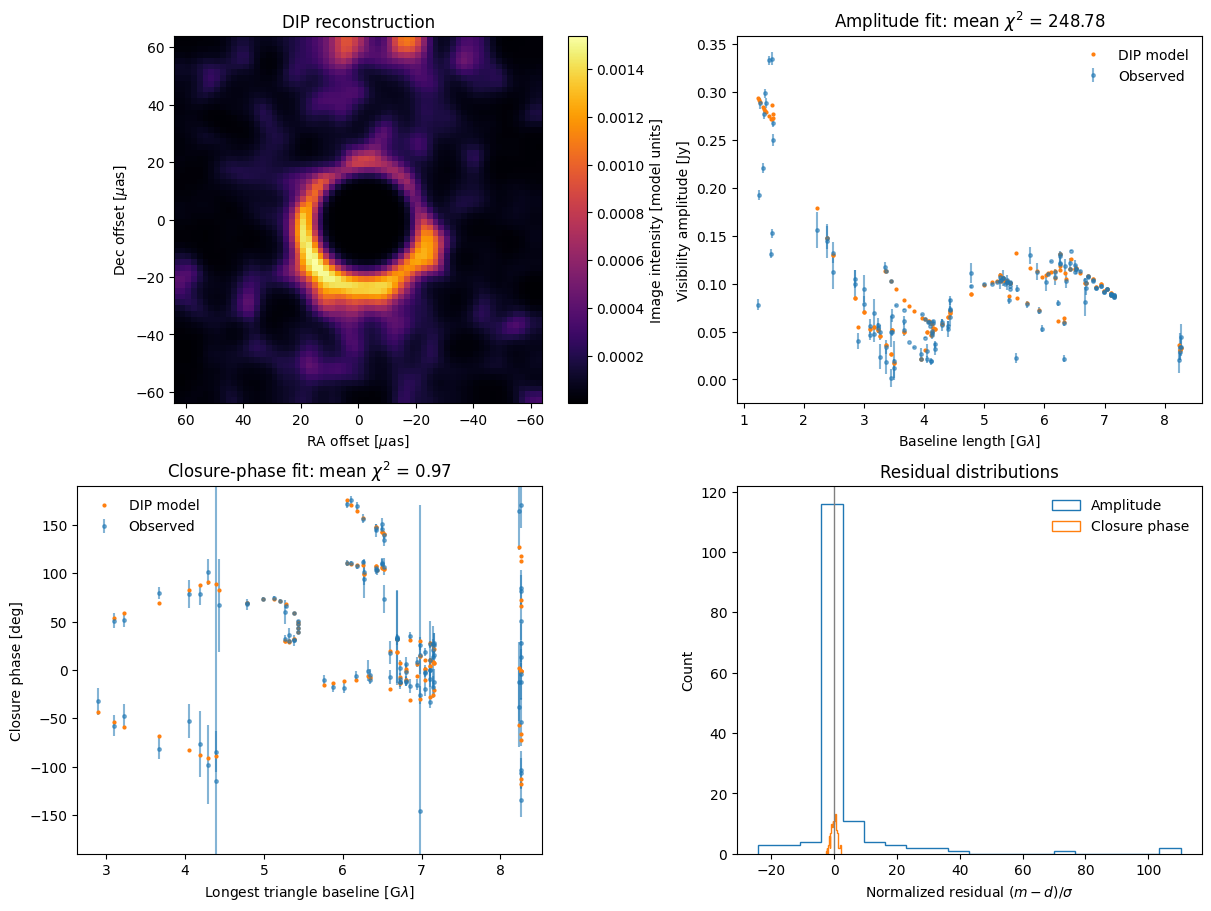

In [9]:
cell_rad = cell_size_rad_from_uas(PIXEL_SIZE_UAS)
model_vis = image_to_vis(image, data["u"], data["v"], cell_rad)
model_amp = np.abs(model_vis)
amp_residual_sigma = (model_amp - data["vis"]) / data["vsigma"]
amp_chi2 = np.mean(amp_residual_sigma**2)

has_cp = cp_keys.issubset(data)
if has_cp:
    model_cp_deg = np.rad2deg(closure_phases_from_image(
        image, data["u1"], data["v1"], data["u2"], data["v2"], cell_rad
    ))
    cp_residual_deg = wrap_degrees(model_cp_deg - data["cphase"])
    cp_residual_sigma = cp_residual_deg / data["sigmacp"]
    cp_chi2 = np.mean(cp_residual_sigma**2)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
half_fov = NPIX * PIXEL_SIZE_UAS / 2
im = axes[0, 0].imshow(
    image, origin="upper", cmap="inferno",
    extent=[half_fov, -half_fov, -half_fov, half_fov],
)
axes[0, 0].set(xlabel=r"RA offset [$\mu$as]", ylabel=r"Dec offset [$\mu$as]", title="DIP reconstruction")
fig.colorbar(im, ax=axes[0, 0], label="Image intensity [JY/pixel]")

order_amp = np.argsort(baseline_glambda)
axes[0, 1].errorbar(baseline_glambda, data["vis"], yerr=data["vsigma"], fmt=".", ms=5, alpha=0.55, label="Observed")
axes[0, 1].plot(baseline_glambda[order_amp], model_amp[order_amp], ".", ms=4, label="DIP model")
axes[0, 1].set(xlabel=r"Baseline length [G$\lambda$]", ylabel="Visibility amplitude [Jy]", title=fr"Amplitude fit: mean $\chi^2$ = {amp_chi2:.2f}")
axes[0, 1].legend(frameon=False)

if has_cp:
    axes[1, 0].errorbar(triangle_scale_glambda, data["cphase"], yerr=data["sigmacp"], fmt=".", ms=5, alpha=0.55, label="Observed")
    axes[1, 0].plot(triangle_scale_glambda, model_cp_deg, ".", ms=4, label="DIP model")
    axes[1, 0].set(xlabel=r"Longest triangle baseline [G$\lambda$]", ylabel="Closure phase [deg]", ylim=(-190, 190), title=fr"Closure-phase fit: mean $\chi^2$ = {cp_chi2:.2f}")
    axes[1, 0].legend(frameon=False)
    axes[1, 1].hist(amp_residual_sigma, bins=20, histtype="step", lw=2, label="Amplitude")
    axes[1, 1].hist(cp_residual_sigma, bins=20, histtype="step", lw=2, label="Closure phase")
else:
    axes[1, 0].text(0.5, 0.5, "No complete closure-phase data", ha="center", va="center")
    axes[1, 0].set_axis_off()
    axes[1, 1].hist(amp_residual_sigma, bins=20, histtype="step", lw=2, label="Amplitude")

axes[1, 1].axvline(0, color="0.5", lw=1)
axes[1, 1].set(xlabel=r"Normalized residual $(m-d)/\sigma$", ylabel="Count", title="Residual distributions")
axes[1, 1].legend(frameon=False)

diagnostic_figure = OUTPUT_DIR / "reconstruction_and_data_fits.png"
fig.savefig(diagnostic_figure, dpi=180, bbox_inches="tight")
plt.show()

### What should you look for?

- **Data agreement:** Do model amplitudes and closure phases follow the measurements within their uncertainties? Look for coherent residual trends with baseline length, not just a single summary number.
- **Optimization convergence:** A 400-step image can still be evolving. Compare it with a longer run before drawing physical conclusions. The function returns the image with the best data-term value encountered, not necessarily the final iterate.
- **Prior sensitivity:** Repeat with weaker/stronger TSV and compactness penalties. A feature that appears only for one narrow choice is prior-sensitive.
- **Translation ambiguity:** Amplitudes and closure phases do not fix absolute image position; centering is supplied implicitly or explicitly by the prior.
- **Angular resolution:** Fine pixels do not guarantee equally fine trustworthy structure. Compare candidate features with the nominal fringe spacing and with reconstructions across seeds/settings.

In [10]:
# Save the raw NumPy image and a simple FITS image. The vertical flip matches
# the convention used by the supplied example runner.
np.save(OUTPUT_DIR / "image_final.npy", image.astype(np.float32))
fits.writeto(
    OUTPUT_DIR / "image_final.fits",
    np.flipud(image).astype(np.float32),
    overwrite=True,
)

model_products = {
    "u": data["u"], "v": data["v"],
    "vis_obs": data["vis"], "vis_sigma": data["vsigma"],
    "vis_model": model_amp,
}
if has_cp:
    model_products.update(
        cphase_obs=data["cphase"], cphase_sigma=data["sigmacp"],
        cphase_model=model_cp_deg,
    )
np.savez(OUTPUT_DIR / "model_observables.npz", **model_products)

archive_path = Path(shutil.make_archive("eht_dip_results", "zip", OUTPUT_DIR))
print(f"Saved {archive_path.resolve()} ({archive_path.stat().st_size/1e6:.2f} MB)")
print("Download it from Colab's Files panel before ending the session.")

DOWNLOAD_NOW = True  #@param {type:"boolean"}
if DOWNLOAD_NOW:
    from google.colab import files
    files.download(str(archive_path))

Saved /content/eht_dip_results.zip (0.26 MB)
Download it from Colab's Files panel before ending the session.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4. Weighted bootstrap

The module can draw Poisson or Dirichlet weights for individual measurements, reconstruct each weighted data set, and summarize the resulting image ensemble. This probes one component of data-sampling variability; it does **not** include every calibration or modeling systematic.

The default below does nothing. Set `RUN_BOOTSTRAP = True` when you are ready. Three short realizations are enough to learn the API but **not** enough to estimate publishable uncertainty. For inference, use many more realizations and demonstrate convergence with respect to both optimization length and ensemble size. Each reconstruction is computationally expensive.

[    1/4000] chi2_amp=1.461e+09 chi2_cp=363.8 tv=54.95(λ=0) tsv=1.488(λ=1) l1=0.4266(λ=0) flux=0(λ=0) comp=0.2898(λ=0.5) void=0(λ=0) cent=0.0004251(λ=0) alpha=0.599
[ 2000/4000] chi2_amp=103.8 chi2_cp=1.103 tv=8.075(λ=0) tsv=2.132e-05(λ=1) l1=0.0002634(λ=0) flux=0(λ=0) comp=0.0001652(λ=0.5) void=0(λ=0) cent=0.0004475(λ=0) alpha=0.583
[ 4000/4000] chi2_amp=103.3 chi2_cp=1.137 tv=8.079(λ=0) tsv=3.097e-05(λ=1) l1=0.0002516(λ=0) flux=0(λ=0) comp=0.0001554(λ=0.5) void=0(λ=0) cent=0.0002135(λ=0) alpha=0.581
[    1/4000] chi2_amp=1.741e+09 chi2_cp=431.6 tv=54.95(λ=0) tsv=1.488(λ=1) l1=0.4266(λ=0) flux=0(λ=0) comp=0.2898(λ=0.5) void=0(λ=0) cent=0.0004251(λ=0) alpha=0.599
[ 2000/4000] chi2_amp=178.9 chi2_cp=1.189 tv=8.078(λ=0) tsv=2.858e-05(λ=1) l1=0.0002247(λ=0) flux=0(λ=0) comp=0.000131(λ=0.5) void=0(λ=0) cent=0.00036(λ=0) alpha=0.583
[ 4000/4000] chi2_amp=195.2 chi2_cp=1.092 tv=8.085(λ=0) tsv=4.316e-05(λ=1) l1=0.0002204(λ=0) flux=0(λ=0) comp=0.0001297(λ=0.5) void=0(λ=0) cent=0.0003969(λ=0) a

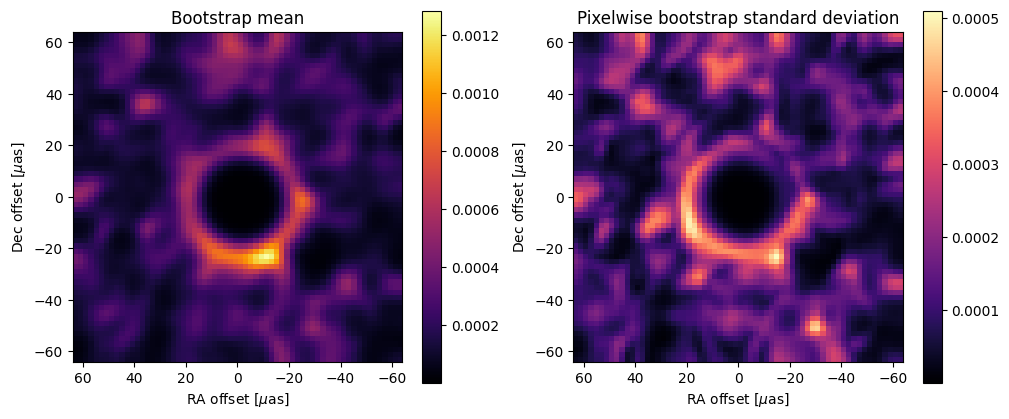

In [12]:
RUN_BOOTSTRAP = True  #@param {type:"boolean"}
BOOTSTRAP_REPLICATES = 10  #@param {type:"integer"}
BOOTSTRAP_ITERATIONS = 4000  #@param {type:"integer"}

if RUN_BOOTSTRAP and BOOTSTRAP_REPLICATES < 2:
    raise ValueError("Use at least two bootstrap realizations to estimate a standard deviation.")

if RUN_BOOTSTRAP:
    bootstrap_dir = OUTPUT_DIR / "bootstrap"
    bootstrap_dir.mkdir(exist_ok=True)
    boot = reconstruct_eht_dip_bootstrap(
        data_dict=data,
        B=BOOTSTRAP_REPLICATES,
        bootstrap_kind="poisson",
        seed=12345,
        do_baseline_map=False,
        warm_start=False,
        reuse_z=False,
        short_num_iter=BOOTSTRAP_ITERATIONS,
        save_dir=str(bootstrap_dir),
        save_stack=True,
        npix=NPIX, pixel_size=PIXEL_SIZE_UAS, device=DEVICE,
        amp_weight=1.5, cp_weight=1.0,
        lambda_tv=0.0, lambda_tsv=1.0,
        lambda_compact=0.5, r_compact_uas=40.0,
        use_t_amp=True, t_nu_amp=3.0,
        use_t_cp=True, t_nu_cp=3.0,
        init_gaussian=True, gauss_fwhm_uas=20.0,
        blur_sigma0_pix=2.0, blur_sigma1_pix=0.0,
        blur_decay_iters=BOOTSTRAP_ITERATIONS,
        learn_global_scale=True, global_scale_init=0.6,
        num_iter=BOOTSTRAP_ITERATIONS,
        out_every=max(1, BOOTSTRAP_ITERATIONS // 2),
    )

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), constrained_layout=True)
    extent = [half_fov, -half_fov, -half_fov, half_fov]
    mean_plot = axes[0].imshow(boot["mean"], origin="upper", cmap="inferno", extent=extent)
    std_plot = axes[1].imshow(boot["std"], origin="upper", cmap="magma", extent=extent)
    axes[0].set_title("Bootstrap mean")
    axes[1].set_title("Pixelwise bootstrap standard deviation")
    for ax in axes:
        ax.set(xlabel=r"RA offset [$\mu$as]", ylabel=r"Dec offset [$\mu$as]")
    fig.colorbar(mean_plot, ax=axes[0])
    fig.colorbar(std_plot, ax=axes[1])
    plt.show()
else:
    print("Bootstrap skipped. Set RUN_BOOTSTRAP = True to run the extension.")

## 5. Exercises:

1. **Resolution check.** Estimate $1/B_{\max}$ in $\mu$as. How many 2-$\mu$as pixels span this scale?

2. **Implicit versus explicit priors.** Set `lambda_tsv=0.5` while leaving the network unchanged. Then increase it (up to 10$^6$). Which structures are controlled by the architecture, and which by TSV?

3. **Compactness prior.** Vary `r_compact_uas` and `lambda_compact`. At what point does the model-data disagreement reveal an overly restrictive support assumption?

4. **Robustness model.** Compare Student-$t$ loss with `use_t_amp=False` and `use_t_cp=False` (Gaussian normalized-squared residuals). Which measurements drive the difference?

5. **Closure phases.** Set `cp_weight=0`. What image degeneracies become more evident even if amplitude residuals remain good?

6. **Reproducibility.** The module currently fixes its internal seed to 42. Modify `ReconConfig.seed`, repeat multiple initializations, and compare image-space variation with the bootstrap variation.

For each experiment, record the parameter change, image, amplitude residuals, closure-phase residuals, and a short physical interpretation.

## Troubleshooting

- **`CUDA is unavailable`:** enable a GPU runtime and rerun from the first cell.
- **File not found:** rerun the upload cell and select both the `.py` and `.npz` files. Filenames must remain unchanged.
- **CUDA out of memory:** restart the runtime, keep `NPIX=64`, and avoid retaining large bootstrap ensembles.
- **NaN/unstable optimization:** restart from the supplied settings, then alter only one parameter; an excessively large learning rate or poorly scaled regularizer can destabilize the fit.
- **The quick-run image looks unfinished:** that is expected. Switch off `QUICK_RUN`, rerun the configuration and reconstruction cells, and compare the data-space diagnostics.
- **Results disappeared:** Colab virtual machines are ephemeral. Download `eht_dip_results.zip` before the session ends.